# Physicochemical condition selection

This notebook analyzes the outputs of the physicochemical AMP vs putative non-AMP pipeline.

The goal is to select a small set of physically interpretable conditioning variables for the conditional generator.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 1. Locate project outputs

The notebook assumes the repository layout:

```
AMP_competition/
├── notebooks/
└── outputs/
    └── physchem/
```

It also works when launched from the repository root.

In [2]:
cwd = Path.cwd().resolve()

if (cwd / "outputs" / "physchem").exists():
    project_root = cwd
elif (cwd.parent / "outputs" / "physchem").exists():
    project_root = cwd.parent
else:
    raise FileNotFoundError(
        "Could not find outputs/physchem. Run the notebook from the repository "
        "root or from the notebooks directory."
    )

output_dir = project_root / "outputs" / "physchem"
output_dir

PosixPath('/content/outputs/physchem')

In [3]:
required_files = {
    "amp": output_dir / "amp_descriptors.csv",
    "nonamp_unmatched": output_dir / "nonamp_unmatched_descriptors.csv",
    "amp_matched": output_dir / "amp_length_matched_descriptors.csv",
    "nonamp_matched": output_dir / "nonamp_length_matched_descriptors.csv",
    "comparison_combined": output_dir / "descriptor_comparison_combined.csv",
    "comparison_matched": output_dir / "descriptor_comparison_length_matched.csv",
    "comparison_unmatched": output_dir / "descriptor_comparison_unmatched.csv",
}

missing = [str(path) for path in required_files.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))

amp_df = pd.read_csv(required_files["amp"])
nonamp_unmatched_df = pd.read_csv(required_files["nonamp_unmatched"])
amp_matched_df = pd.read_csv(required_files["amp_matched"])
nonamp_matched_df = pd.read_csv(required_files["nonamp_matched"])
comparison_combined = pd.read_csv(required_files["comparison_combined"])
comparison_matched = pd.read_csv(required_files["comparison_matched"])
comparison_unmatched = pd.read_csv(required_files["comparison_unmatched"])

print(f"AMP: {len(amp_df):,}")
print(f"Unmatched non-AMP: {len(nonamp_unmatched_df):,}")
print(f"Length-matched AMP: {len(amp_matched_df):,}")
print(f"Length-matched non-AMP: {len(nonamp_matched_df):,}")

AMP: 39,448
Unmatched non-AMP: 39,448
Length-matched AMP: 35,627
Length-matched non-AMP: 35,627


## 2. Sanity check: length matching

The matched AMP and non-AMP cohorts should have identical empirical length distributions. Therefore length itself must have zero separation in this control cohort.

In [4]:
amp_length_counts = amp_matched_df["length"].value_counts().sort_index()
nonamp_length_counts = nonamp_matched_df["length"].value_counts().sort_index()

length_check = pd.concat(
    [
        amp_length_counts.rename("AMP"),
        nonamp_length_counts.rename("nonAMP"),
    ],
    axis=1,
).fillna(0).astype(int)

length_check["difference"] = length_check["AMP"] - length_check["nonAMP"]

print("Maximum absolute per-length count difference:",
      int(length_check["difference"].abs().max()))
print("Exact match:", bool((length_check["difference"] == 0).all()))

length_check

Maximum absolute per-length count difference: 0
Exact match: True


,AMP,nonAMP,difference
length,,,
8,1299,1299,0
9,1713,1713,0
10,1595,1595,0
11,1561,1561,0
12,2189,2189,0
13,2264,2264,0
14,1417,1417,0
15,1828,1828,0
16,1278,1278,0


## 3. Main descriptor comparison

For selection, prioritize the **length-matched** results.

Useful quantities:

- `cliffs_delta`: directional rank-based effect size;
- `ks_statistic`: maximum difference between empirical CDFs;
- `wasserstein_pooled_iqr`: normalized whole-distribution distance.

Absolute effect size is shown only for convenient inspection. It is not a composite ranking criterion.

In [5]:
matched_summary = comparison_matched[
    [
        "descriptor",
        "amp_median",
        "nonamp_median",
        "cliffs_delta",
        "ks_statistic",
        "wasserstein_pooled_iqr",
    ]
].copy()

matched_summary["abs_cliffs_delta"] = matched_summary["cliffs_delta"].abs()

matched_summary.sort_values(
    ["abs_cliffs_delta", "ks_statistic"],
    ascending=False,
)

,descriptor,amp_median,nonamp_median,cliffs_delta,ks_statistic,wasserstein_pooled_iqr,abs_cliffs_delta
2,charge_pH7_4,2.850347,0.709595,0.428283,0.351391,0.713336,0.428283
3,isoelectric_point,10.789009,8.226201,0.402277,0.323603,0.395091,0.402277
4,fraction_basic_KR,0.190476,0.105263,0.383750,0.297836,0.587193,0.383750
5,fraction_acidic_DE,0.000000,0.076923,-0.321998,0.275353,0.391739,0.321998
11,hydrophobic_moment_alpha,0.499230,0.384900,0.319313,0.242906,0.426027,0.319313
16,hydrophobicity_octanolScale_pH8,-0.063000,0.145385,-0.309997,0.216437,0.422616,0.309997
15,hydrophobicity_interfaceScale_pH8,-0.095455,0.000667,-0.308763,0.224942,0.473091,0.308763
17,hydrophobicity_oiScale_pH8,0.008667,0.100500,-0.244702,0.175176,0.321420,0.244702
13,hydrophobicity_Eisenberg,-0.026000,0.041429,-0.145620,0.114548,0.247063,0.145620
7,fraction_aromatic,0.095238,0.076923,0.125800,0.098858,0.218056,0.125800


## 4. Effect before and after length control

This table helps distinguish genuine descriptor effects from differences driven mainly by peptide length.

In [6]:
before_after = comparison_combined[
    [
        "descriptor",
        "cliffs_delta_unmatched",
        "cliffs_delta_length_matched",
        "ks_statistic_unmatched",
        "ks_statistic_length_matched",
        "wasserstein_pooled_iqr_unmatched",
        "wasserstein_pooled_iqr_length_matched",
    ]
].copy()

before_after["delta_change"] = (
    before_after["cliffs_delta_length_matched"]
    - before_after["cliffs_delta_unmatched"]
)

before_after.sort_values(
    "cliffs_delta_length_matched",
    key=lambda s: s.abs(),
    ascending=False,
)

,descriptor,cliffs_delta_unmatched,cliffs_delta_length_matched,ks_statistic_unmatched,ks_statistic_length_matched,wasserstein_pooled_iqr_unmatched,wasserstein_pooled_iqr_length_matched,delta_change
1,charge_pH7_4,0.284321,0.428283,0.226197,0.351391,0.426804,0.713336,0.143961
15,isoelectric_point,0.369544,0.402277,0.308761,0.323603,0.355648,0.395091,0.032733
6,fraction_basic_KR,0.370366,0.383750,0.361793,0.297836,0.660099,0.587193,0.013383
4,fraction_acidic_DE,-0.507087,-0.321998,0.486412,0.275353,0.469032,0.391739,0.185090
8,hydrophobic_moment_alpha,-0.104181,0.319313,0.166396,0.242906,0.285837,0.426027,0.423494
13,hydrophobicity_octanolScale_pH8,-0.436916,-0.309997,0.327418,0.216437,0.583896,0.422616,0.126919
12,hydrophobicity_interfaceScale_pH8,-0.411386,-0.308763,0.311701,0.224942,0.629309,0.473091,0.102623
14,hydrophobicity_oiScale_pH8,-0.374407,-0.244702,0.299432,0.175176,0.477046,0.321420,0.129705
10,hydrophobicity_Eisenberg,-0.138196,-0.145620,0.154380,0.114548,0.288087,0.247063,-0.007425
5,fraction_aromatic,0.111997,0.125800,0.183305,0.098858,0.404542,0.218056,0.013802


## 5. Candidate families

The current candidate logic is concept-based rather than descriptor-based.

**Electrostatics**
- net charge at pH 7.4
- isoelectric point
- basic-residue fraction
- acidic-residue fraction

**Hydrophobicity**
- membrane/interface-oriented scales are of primary interest
- Eisenberg and Kyte-Doolittle are retained as reference operationalizations

**Possible third factor**
- aromatic fraction
- Boman index
- GP fraction
- Cys fraction

Hydrophobic moment is intentionally excluded from the conditioning shortlist because it assumes a periodic structural organization that is not universal across AMP classes.

In [7]:
electrostatic = [
    "charge_pH7_4",
    "isoelectric_point",
    "fraction_basic_KR",
    "fraction_acidic_DE",
]

hydrophobicity = [
    "hydrophobicity_Eisenberg",
    "hydrophobicity_KyteDoolittle",
    "hydrophobicity_interfaceScale_pH8",
    "hydrophobicity_octanolScale_pH8",
    "hydrophobicity_oiScale_pH8",
    "fraction_hydrophobic",
]

residual_candidates = [
    "fraction_aromatic",
    "boman_index",
    "fraction_GP",
    "fraction_C",
]

excluded_from_conditioning = [
    "length",
    "molecular_weight",
    "hydrophobic_moment_alpha",
    "hydrophobic_moment_beta",
]

def family_table(descriptors):
    table = comparison_matched[
        comparison_matched["descriptor"].isin(descriptors)
    ][
        [
            "descriptor",
            "amp_median",
            "nonamp_median",
            "cliffs_delta",
            "ks_statistic",
            "wasserstein_pooled_iqr",
        ]
    ].copy()
    table["abs_cliffs_delta"] = table["cliffs_delta"].abs()
    return table.sort_values("abs_cliffs_delta", ascending=False)

print("Electrostatics")
display(family_table(electrostatic))

print("Hydrophobicity")
display(family_table(hydrophobicity))

print("Possible third factor")
display(family_table(residual_candidates))

Electrostatics


,descriptor,amp_median,nonamp_median,cliffs_delta,ks_statistic,wasserstein_pooled_iqr,abs_cliffs_delta
2,charge_pH7_4,2.850347,0.709595,0.428283,0.351391,0.713336,0.428283
3,isoelectric_point,10.789009,8.226201,0.402277,0.323603,0.395091,0.402277
4,fraction_basic_KR,0.190476,0.105263,0.383750,0.297836,0.587193,0.383750
5,fraction_acidic_DE,0.000000,0.076923,-0.321998,0.275353,0.391739,0.321998


Hydrophobicity


,descriptor,amp_median,nonamp_median,cliffs_delta,ks_statistic,wasserstein_pooled_iqr,abs_cliffs_delta
16,hydrophobicity_octanolScale_pH8,-0.063000,0.145385,-0.309997,0.216437,0.422616,0.309997
15,hydrophobicity_interfaceScale_pH8,-0.095455,0.000667,-0.308763,0.224942,0.473091,0.308763
17,hydrophobicity_oiScale_pH8,0.008667,0.100500,-0.244702,0.175176,0.321420,0.244702
13,hydrophobicity_Eisenberg,-0.026000,0.041429,-0.145620,0.114548,0.247063,0.145620
14,hydrophobicity_KyteDoolittle,-0.242857,-0.150000,-0.073428,0.065624,0.126054,0.073428
6,fraction_hydrophobic,0.437500,0.421053,0.038135,0.044152,0.061814,0.038135


Possible third factor


,descriptor,amp_median,nonamp_median,cliffs_delta,ks_statistic,wasserstein_pooled_iqr,abs_cliffs_delta
7,fraction_aromatic,0.095238,0.076923,0.125800,0.098858,0.218056,0.125800
10,boman_index,1.444091,1.385714,0.041994,0.071743,0.126949,0.041994
9,fraction_C,0.000000,0.000000,-0.017913,0.028153,0.063117,0.017913
8,fraction_GP,0.100000,0.100000,0.008523,0.045415,0.094250,0.008523


## 6. Correlation matrices within each class

Correlations are calculated separately for matched AMP and matched non-AMP cohorts. This avoids mixing class separation with within-class redundancy.

Spearman correlation is used because the descriptors need not be normally distributed or linearly related.

In [8]:
candidate_descriptors = electrostatic + hydrophobicity + residual_candidates

amp_corr = amp_matched_df[candidate_descriptors].corr(method="spearman")
nonamp_corr = nonamp_matched_df[candidate_descriptors].corr(method="spearman")

amp_corr.to_csv(output_dir / "candidate_spearman_amp_matched.csv")
nonamp_corr.to_csv(output_dir / "candidate_spearman_nonamp_matched.csv")

display(amp_corr.round(3))
display(nonamp_corr.round(3))

,charge_pH7_4,isoelectric_point,fraction_basic_KR,fraction_acidic_DE,hydrophobicity_Eisenberg,hydrophobicity_KyteDoolittle,hydrophobicity_interfaceScale_pH8,hydrophobicity_octanolScale_pH8,hydrophobicity_oiScale_pH8,fraction_hydrophobic,fraction_aromatic,boman_index,fraction_GP,fraction_C
charge_pH7_4,1.000,0.890,0.857,-0.533,-0.533,-0.296,-0.301,-0.440,-0.435,-0.041,-0.005,0.332,-0.111,-0.225
isoelectric_point,0.890,1.000,0.822,-0.596,-0.525,-0.271,-0.348,-0.526,-0.536,0.039,0.018,0.391,-0.125,-0.335
fraction_basic_KR,0.857,0.822,1.000,-0.352,-0.718,-0.445,-0.276,-0.383,-0.367,-0.086,0.019,0.509,-0.295,-0.244
fraction_acidic_DE,-0.533,-0.596,-0.352,1.000,-0.020,-0.153,0.567,0.757,0.716,-0.266,-0.122,0.153,-0.013,0.075
hydrophobicity_Eisenberg,-0.533,-0.525,-0.718,-0.020,1.000,0.862,-0.144,-0.106,-0.091,0.584,0.007,-0.940,0.218,0.085
hydrophobicity_KyteDoolittle,-0.296,-0.271,-0.445,-0.153,0.862,1.000,-0.194,-0.261,-0.310,0.709,-0.188,-0.858,0.004,0.107
hydrophobicity_interfaceScale_pH8,-0.301,-0.348,-0.276,0.567,-0.144,-0.194,1.000,0.855,0.607,-0.517,-0.601,0.237,0.191,0.083
hydrophobicity_octanolScale_pH8,-0.440,-0.526,-0.383,0.757,-0.106,-0.261,0.855,1.000,0.915,-0.567,-0.394,0.239,0.242,0.166
hydrophobicity_oiScale_pH8,-0.435,-0.536,-0.367,0.716,-0.091,-0.310,0.607,0.915,1.000,-0.524,-0.153,0.224,0.248,0.198
fraction_hydrophobic,-0.041,0.039,-0.086,-0.266,0.584,0.709,-0.517,-0.567,-0.524,1.000,0.188,-0.631,-0.308,-0.256


,charge_pH7_4,isoelectric_point,fraction_basic_KR,fraction_acidic_DE,hydrophobicity_Eisenberg,hydrophobicity_KyteDoolittle,hydrophobicity_interfaceScale_pH8,hydrophobicity_octanolScale_pH8,hydrophobicity_oiScale_pH8,fraction_hydrophobic,fraction_aromatic,boman_index,fraction_GP,fraction_C
charge_pH7_4,1.000,0.962,0.714,-0.611,-0.326,-0.136,-0.298,-0.465,-0.462,-0.058,-0.022,0.202,-0.045,-0.060
isoelectric_point,0.962,1.000,0.724,-0.603,-0.346,-0.152,-0.272,-0.447,-0.452,-0.073,-0.051,0.231,-0.039,-0.080
fraction_basic_KR,0.714,0.724,1.000,-0.033,-0.717,-0.491,0.058,0.015,-0.001,-0.315,-0.122,0.600,-0.133,-0.035
fraction_acidic_DE,-0.611,-0.603,-0.033,1.000,-0.293,-0.369,0.593,0.802,0.759,-0.275,-0.121,0.377,-0.048,-0.092
hydrophobicity_Eisenberg,-0.326,-0.346,-0.717,-0.293,1.000,0.911,-0.474,-0.498,-0.451,0.754,0.271,-0.972,0.057,0.047
hydrophobicity_KyteDoolittle,-0.136,-0.152,-0.491,-0.369,0.911,1.000,-0.528,-0.605,-0.584,0.827,0.159,-0.913,-0.101,0.141
hydrophobicity_interfaceScale_pH8,-0.298,-0.272,0.058,0.593,-0.474,-0.528,1.000,0.829,0.623,-0.582,-0.601,0.504,0.165,-0.129
hydrophobicity_octanolScale_pH8,-0.465,-0.447,0.015,0.802,-0.498,-0.605,0.829,1.000,0.941,-0.621,-0.407,0.571,0.208,-0.089
hydrophobicity_oiScale_pH8,-0.462,-0.452,-0.001,0.759,-0.451,-0.584,0.623,0.941,1.000,-0.577,-0.218,0.533,0.240,-0.038
fraction_hydrophobic,-0.058,-0.073,-0.315,-0.275,0.754,0.827,-0.582,-0.621,-0.577,1.000,0.380,-0.764,-0.304,-0.083


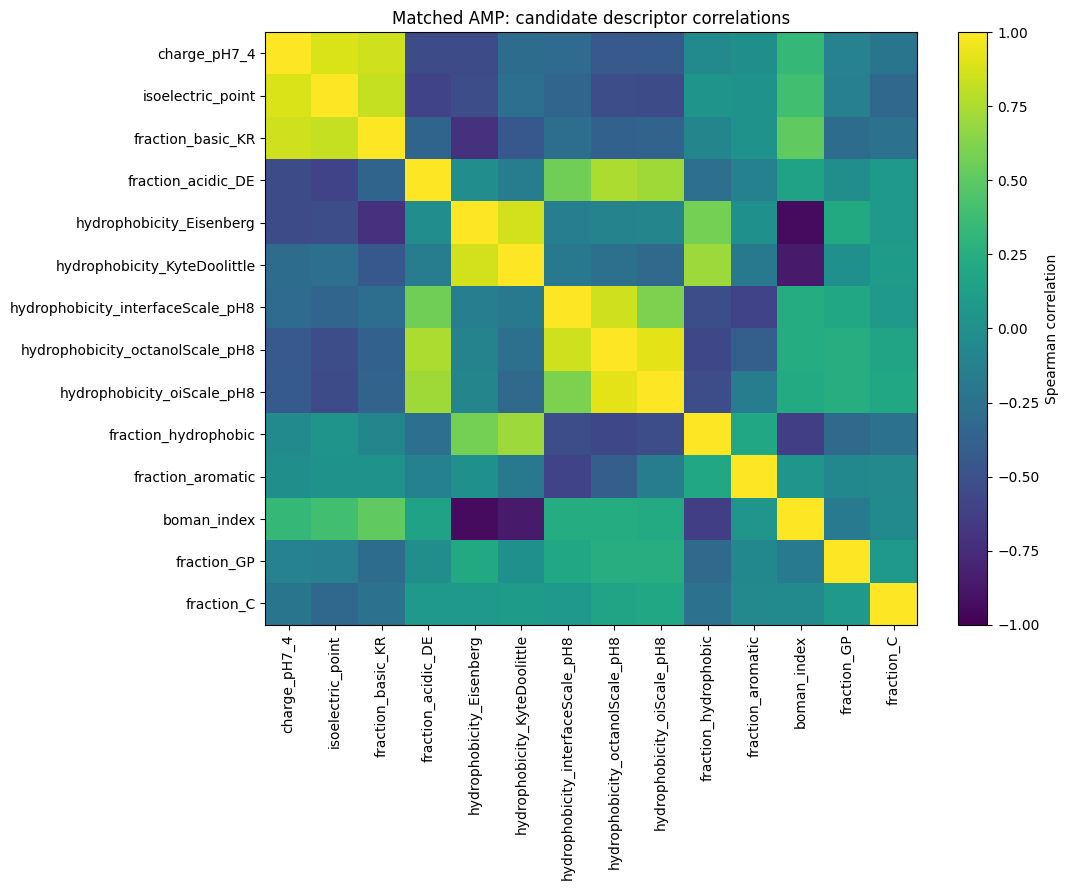

In [9]:
def plot_corr_matrix(corr, title):
    fig, ax = plt.subplots(figsize=(11, 9))
    image = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.index)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="Spearman correlation")
    fig.tight_layout()
    plt.show()

plot_corr_matrix(amp_corr, "Matched AMP: candidate descriptor correlations")

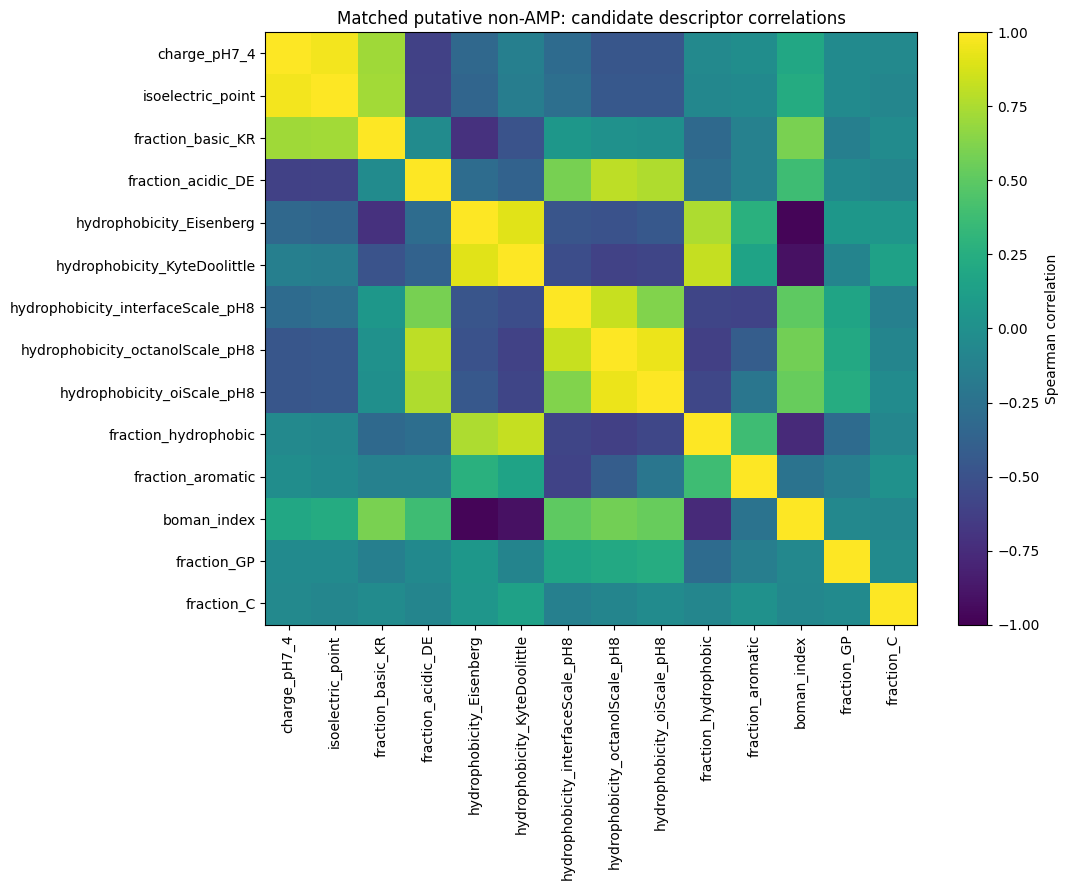

In [10]:
plot_corr_matrix(
    nonamp_corr,
    "Matched putative non-AMP: candidate descriptor correlations",
)

## 7. Within-family redundancy

These compact matrices are the main basis for choosing one operationalization from each physical family.

In [11]:
print("Electrostatics — AMP")
display(amp_corr.loc[electrostatic, electrostatic].round(3))

print("Electrostatics — non-AMP")
display(nonamp_corr.loc[electrostatic, electrostatic].round(3))

print("Hydrophobicity — AMP")
display(amp_corr.loc[hydrophobicity, hydrophobicity].round(3))

print("Hydrophobicity — non-AMP")
display(nonamp_corr.loc[hydrophobicity, hydrophobicity].round(3))

Electrostatics — AMP


,charge_pH7_4,isoelectric_point,fraction_basic_KR,fraction_acidic_DE
charge_pH7_4,1.000,0.890,0.857,-0.533
isoelectric_point,0.890,1.000,0.822,-0.596
fraction_basic_KR,0.857,0.822,1.000,-0.352
fraction_acidic_DE,-0.533,-0.596,-0.352,1.000


Electrostatics — non-AMP


,charge_pH7_4,isoelectric_point,fraction_basic_KR,fraction_acidic_DE
charge_pH7_4,1.000,0.962,0.714,-0.611
isoelectric_point,0.962,1.000,0.724,-0.603
fraction_basic_KR,0.714,0.724,1.000,-0.033
fraction_acidic_DE,-0.611,-0.603,-0.033,1.000


Hydrophobicity — AMP


,hydrophobicity_Eisenberg,hydrophobicity_KyteDoolittle,hydrophobicity_interfaceScale_pH8,hydrophobicity_octanolScale_pH8,hydrophobicity_oiScale_pH8,fraction_hydrophobic
hydrophobicity_Eisenberg,1.000,0.862,-0.144,-0.106,-0.091,0.584
hydrophobicity_KyteDoolittle,0.862,1.000,-0.194,-0.261,-0.310,0.709
hydrophobicity_interfaceScale_pH8,-0.144,-0.194,1.000,0.855,0.607,-0.517
hydrophobicity_octanolScale_pH8,-0.106,-0.261,0.855,1.000,0.915,-0.567
hydrophobicity_oiScale_pH8,-0.091,-0.310,0.607,0.915,1.000,-0.524
fraction_hydrophobic,0.584,0.709,-0.517,-0.567,-0.524,1.000


Hydrophobicity — non-AMP


,hydrophobicity_Eisenberg,hydrophobicity_KyteDoolittle,hydrophobicity_interfaceScale_pH8,hydrophobicity_octanolScale_pH8,hydrophobicity_oiScale_pH8,fraction_hydrophobic
hydrophobicity_Eisenberg,1.000,0.911,-0.474,-0.498,-0.451,0.754
hydrophobicity_KyteDoolittle,0.911,1.000,-0.528,-0.605,-0.584,0.827
hydrophobicity_interfaceScale_pH8,-0.474,-0.528,1.000,0.829,0.623,-0.582
hydrophobicity_octanolScale_pH8,-0.498,-0.605,0.829,1.000,0.941,-0.621
hydrophobicity_oiScale_pH8,-0.451,-0.584,0.623,0.941,1.000,-0.577
fraction_hydrophobic,0.754,0.827,-0.582,-0.621,-0.577,1.000


## 8. Pairwise visual inspection

Use the matched cohorts so the plots are not dominated by differences in peptide length.

The function samples points only for visualization; all numerical statistics above use the complete cohorts.

In [12]:
def plot_pair(
    x,
    y,
    *,
    sample_size=5000,
    seed=42,
):
    amp_plot = amp_matched_df[[x, y]].dropna()
    nonamp_plot = nonamp_matched_df[[x, y]].dropna()

    if len(amp_plot) > sample_size:
        amp_plot = amp_plot.sample(sample_size, random_state=seed)
    if len(nonamp_plot) > sample_size:
        nonamp_plot = nonamp_plot.sample(sample_size, random_state=seed)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(
        amp_plot[x],
        amp_plot[y],
        s=8,
        alpha=0.25,
        label="AMP",
    )
    ax.scatter(
        nonamp_plot[x],
        nonamp_plot[y],
        s=8,
        alpha=0.25,
        label="putative non-AMP",
    )
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend()
    ax.set_title(f"{x} vs {y}")
    fig.tight_layout()
    plt.show()

### Electrostatic family

Net charge at pH 7.4 is the current primary electrostatic candidate. Compare it against the alternative operationalizations.

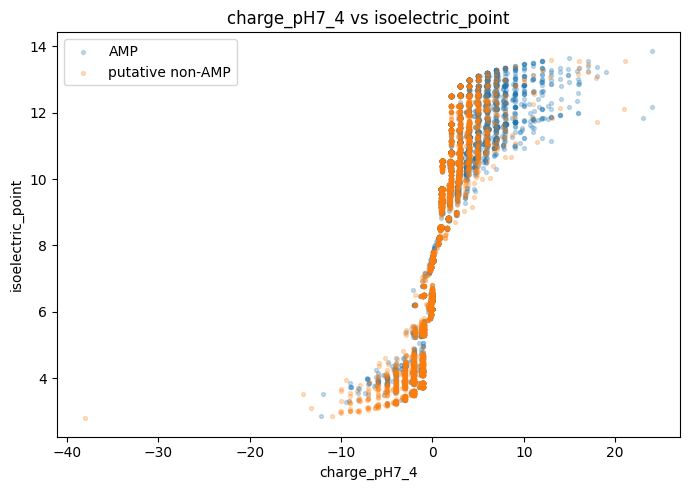

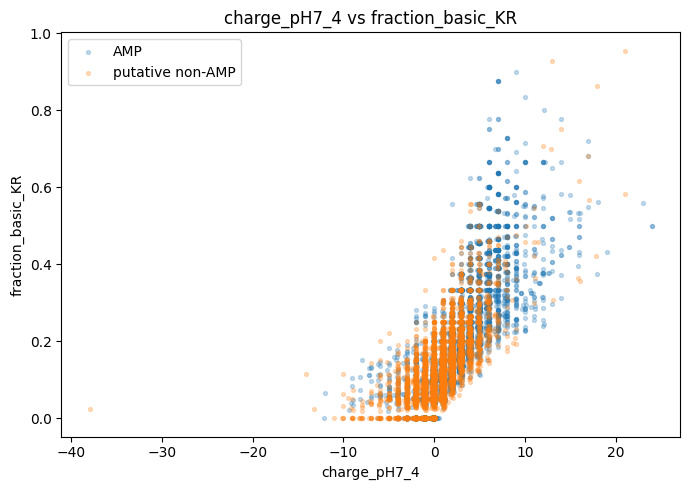

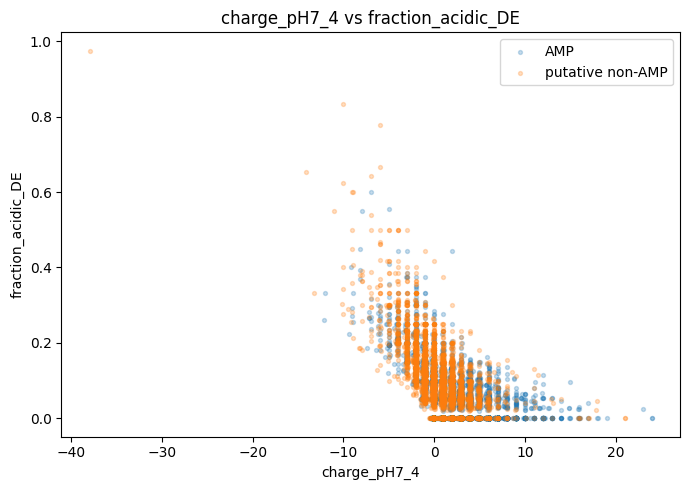

In [13]:
for alternative in [
    "isoelectric_point",
    "fraction_basic_KR",
    "fraction_acidic_DE",
]:
    plot_pair("charge_pH7_4", alternative)

### Hydrophobicity family

`interfaceScale_pH8` and `octanolScale_pH8` are the current strongest candidates from the marginal comparison.

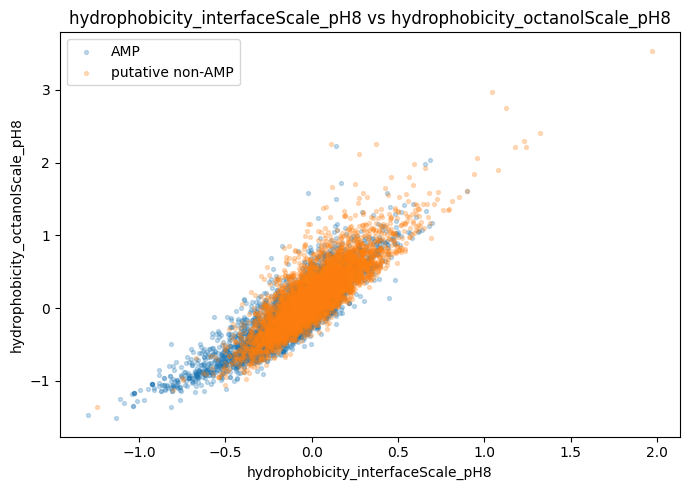

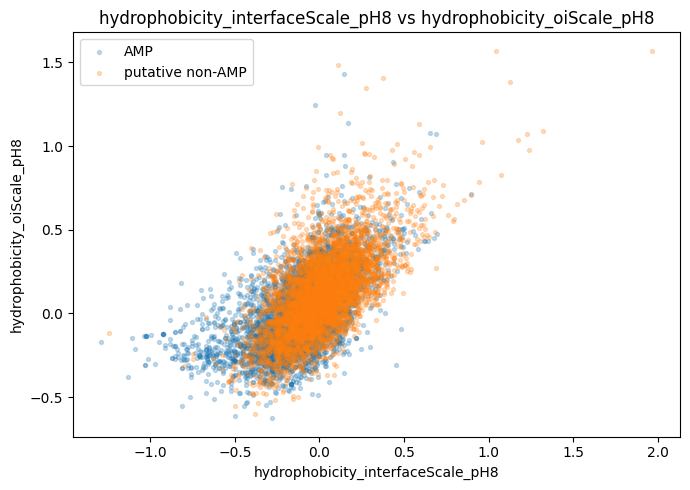

In [14]:
plot_pair(
    "hydrophobicity_interfaceScale_pH8",
    "hydrophobicity_octanolScale_pH8",
)

plot_pair(
    "hydrophobicity_interfaceScale_pH8",
    "hydrophobicity_oiScale_pH8",
)

## 9. Search for a possible independent third factor

A third condition should satisfy two requirements:

1. retain a meaningful AMP/non-AMP difference after length control;
2. not simply reproduce the selected electrostatic or hydrophobicity coordinate.

This section reports both marginal separation and correlations with the two current reference candidates.

In [16]:
reference_candidates = [
    "charge_pH7_4",
    "hydrophobicity_interfaceScale_pH8",
]

rows = []

for descriptor in residual_candidates:
    stats = comparison_matched.loc[
        comparison_matched["descriptor"] == descriptor
    ].iloc[0]

    rows.append(
        {
            "descriptor": descriptor,
            "cliffs_delta": stats["cliffs_delta"],
            "ks_statistic": stats["ks_statistic"],
            "wasserstein_pooled_iqr": stats["wasserstein_pooled_iqr"],
            "rho_charge_AMP": amp_corr.loc[
                descriptor, "charge_pH7_4"
            ],
            "rho_charge_nonAMP": nonamp_corr.loc[
                descriptor, "charge_pH7_4"
            ],
            "rho_hydrophobicity_AMP": amp_corr.loc[
                descriptor, "hydrophobicity_interfaceScale_pH8"
            ],
            "rho_hydrophobicity_nonAMP": nonamp_corr.loc[
                descriptor, "hydrophobicity_interfaceScale_pH8"
            ],
        }
    )

third_factor_table = pd.DataFrame(rows)
third_factor_table

,descriptor,cliffs_delta,ks_statistic,wasserstein_pooled_iqr,rho_charge_AMP,rho_charge_nonAMP,rho_hydrophobicity_AMP,rho_hydrophobicity_nonAMP
0,fraction_aromatic,0.125800,0.098858,0.218056,-0.004686,-0.022421,-0.600739,-0.600595
1,boman_index,0.041994,0.071743,0.126949,0.332115,0.201584,0.237396,0.503797
2,fraction_GP,0.008523,0.045415,0.094250,-0.110837,-0.045198,0.191413,0.165243
3,fraction_C,-0.017913,0.028153,0.063117,-0.225374,-0.059769,0.083059,-0.128697


## 10. Current shortlist

This is intentionally explicit rather than automatically optimized.

Current default interpretation before inspecting the correlation results:

- **electrostatics:** `charge_pH7_4`;
- **hydrophobicity:** `hydrophobicity_interfaceScale_pH8`;


Edit the list below only after inspecting the cells above.

In [17]:
selected_conditions = [
    "charge_pH7_4",
    "hydrophobicity_interfaceScale_pH8"
]

selected_conditions

['charge_pH7_4', 'hydrophobicity_interfaceScale_pH8']

## 11. Preview of the selected joint condition space

This is only a visualization of the selected coordinates.

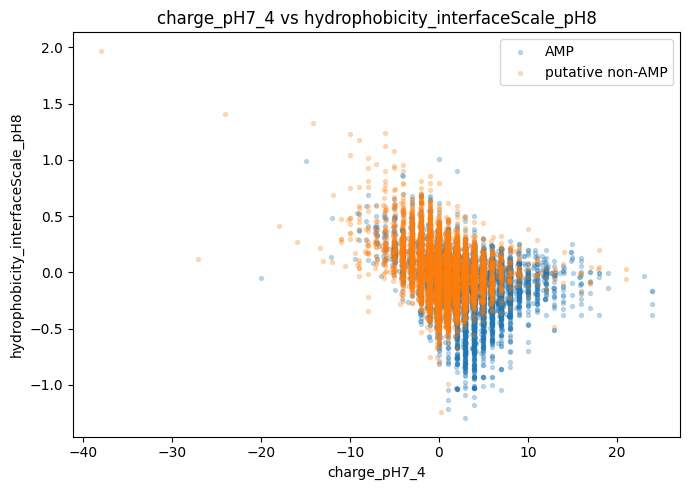

In [18]:
if len(selected_conditions) == 2:
    plot_pair(
        selected_conditions[0],
        selected_conditions[1],
        sample_size=10000,
    )
else:
    print(
        "Joint-space preview is configured for two conditions. "
    )

## 12. Decision record

**Selected electrostatic descriptor:**  
`charge_pH7_4`

**Reason:**  
Net charge at pH 7.4 showed the strongest length-controlled separation within the electrostatic family (Cliff's δ = 0.428, KS = 0.351, normalized Wasserstein = 0.713). It is strongly correlated with alternative electrostatic descriptors such as isoelectric point and basic-residue fraction, making their simultaneous inclusion largely redundant. Net charge was selected as the most direct and physically interpretable representation of peptide electrostatics.

**Selected hydrophobicity descriptor:**  
`hydrophobicity_interfaceScale_pH8`

**Reason:**  
The interface-scale hydrophobicity showed substantial length-controlled separation between AMP and putative non-AMP sequences (Cliff's δ = -0.309, KS = 0.225, normalized Wasserstein = 0.473). Its performance was comparable to the octanol scale, while the two descriptors were strongly correlated. The interface scale was selected as a single representative of membrane-related hydrophobicity because of its direct relevance to peptide interactions with membrane interfaces.

**Third descriptor:**  
None.

**Reason:**  
No additional descriptor combined sufficiently strong length-controlled separation with clear independence from the selected electrostatic and hydrophobicity coordinates. Aromatic fraction retained some separation but was substantially correlated with interface-scale hydrophobicity, whereas Boman index, GP fraction, and Cys fraction showed weak effects. Adding a third condition would therefore increase dimensionality without clear evidence of additional physicochemical information.

**Excluded descriptors and rationale:**  
Length was excluded as a conditioning variable because sequence length can be controlled directly during generation and was used here as a matching variable to identify length-independent physicochemical effects. Molecular weight largely reflected sequence length. Hydrophobic moments were excluded despite the signal observed for the alpha-helical moment because they impose a structural periodicity assumption that is not universal across AMP classes. Alternative electrostatic and hydrophobicity descriptors were excluded primarily because they represented redundant operationalizations of the selected physical factors.

**Final condition space:**  
The physicochemical conditioning space is defined as

`c = (charge_pH7_4, hydrophobicity_interfaceScale_pH8)`.

The joint-space visualization shows substantial overlap between AMP and putative non-AMP sequences, as expected, but also suggests non-uniform class occupancy across the two-dimensional space. In particular, AMP sequences appear relatively enriched in parts of the positively charged and lower interface-scale hydrophobicity region. This visual pattern should not be interpreted as a quantitative decision boundary.


## 13. Joint AMP enrichment in the selected condition space

The goal is to identify regions of the joint physicochemical space that are enriched in AMP sequences relative to length-matched putative non-AMP sequences.

For the selected condition vector

`c = (charge_pH7_4, hydrophobicity_interfaceScale_pH8)`

we estimate class-conditional densities

`p(c | AMP)` and `p(c | nonAMP)`

using two-dimensional kernel density estimation.

Local enrichment is defined as

`E(c) = p(c | AMP) / p(c | nonAMP)`

and analyzed in log-space:

`log E(c) = log p(c | AMP) - log p(c | nonAMP)`.

This is used only to characterize the physicochemical condition space, not as an AMP classifier.

In [19]:
from scipy.stats import gaussian_kde

In [20]:
charge_col = "charge_pH7_4"
hydro_col = "hydrophobicity_interfaceScale_pH8"

amp_joint = (
    amp_matched_df[[charge_col, hydro_col]]
    .dropna()
    .to_numpy()
    .T
)

nonamp_joint = (
    nonamp_matched_df[[charge_col, hydro_col]]
    .dropna()
    .to_numpy()
    .T
)

print("AMP points:", amp_joint.shape[1])
print("non-AMP points:", nonamp_joint.shape[1])

AMP points: 35627
non-AMP points: 35627


In [21]:
combined_joint = pd.concat(
    [
        amp_matched_df[[charge_col, hydro_col]],
        nonamp_matched_df[[charge_col, hydro_col]],
    ],
    ignore_index=True,
).dropna()

charge_min, charge_max = combined_joint[charge_col].quantile([0.005, 0.995])
hydro_min, hydro_max = combined_joint[hydro_col].quantile([0.005, 0.995])

print("Charge range:", charge_min, charge_max)
print("Hydrophobicity range:", hydro_min, hydro_max)

Charge range: -6.9639503811761925 12.988206143950396
Hydrophobicity range: -0.7962500000000001 0.5758369230769234


In [22]:
amp_kde = gaussian_kde(amp_joint)
nonamp_kde = gaussian_kde(nonamp_joint)

grid_size = 200

charge_grid = np.linspace(charge_min, charge_max, grid_size)
hydro_grid = np.linspace(hydro_min, hydro_max, grid_size)

charge_mesh, hydro_mesh = np.meshgrid(
    charge_grid,
    hydro_grid,
)

grid_points = np.vstack(
    [
        charge_mesh.ravel(),
        hydro_mesh.ravel(),
    ]
)

amp_density = amp_kde(grid_points).reshape(charge_mesh.shape)
nonamp_density = nonamp_kde(grid_points).reshape(charge_mesh.shape)

In [23]:
density_floor = 1e-12

log_enrichment = (
    np.log(amp_density + density_floor)
    - np.log(nonamp_density + density_floor)
)

enrichment = np.exp(log_enrichment)

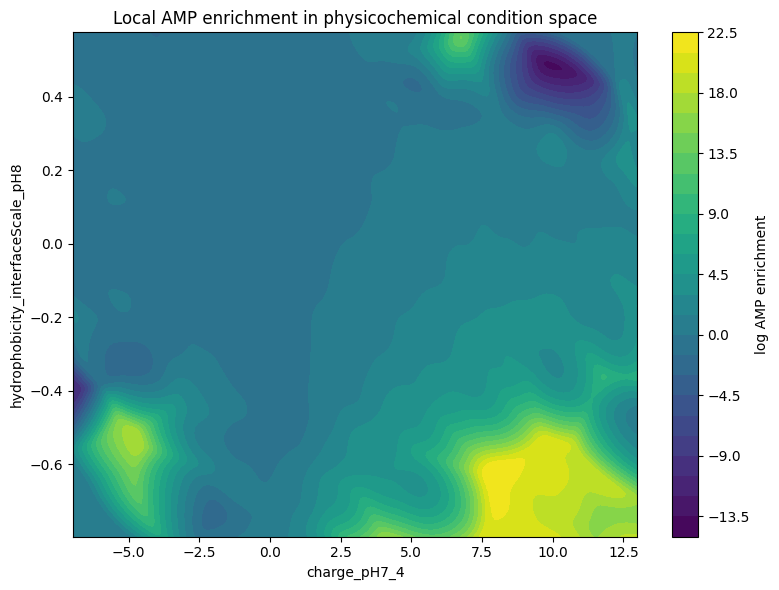

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

contour = ax.contourf(
    charge_mesh,
    hydro_mesh,
    log_enrichment,
    levels=30,
)

fig.colorbar(
    contour,
    ax=ax,
    label="log AMP enrichment",
)

ax.set_xlabel(charge_col)
ax.set_ylabel(hydro_col)
ax.set_title("Local AMP enrichment in physicochemical condition space")

fig.tight_layout()
plt.show()

In [25]:
total_density = amp_density + nonamp_density

density_threshold = np.quantile(
    total_density[total_density > 0],
    0.10,
)

valid_region = total_density >= density_threshold

masked_log_enrichment = np.ma.masked_where(
    ~valid_region,
    log_enrichment,
)

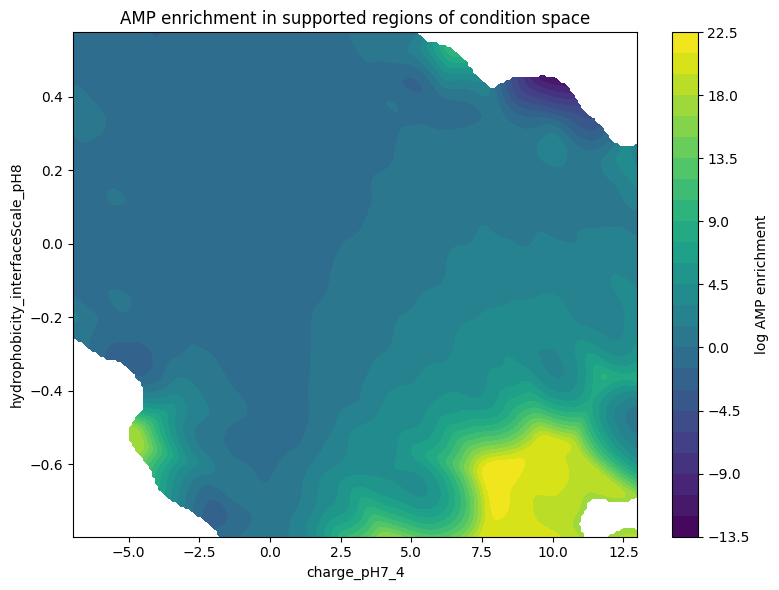

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))

contour = ax.contourf(
    charge_mesh,
    hydro_mesh,
    masked_log_enrichment,
    levels=30,
)

fig.colorbar(
    contour,
    ax=ax,
    label="log AMP enrichment",
)

ax.set_xlabel(charge_col)
ax.set_ylabel(hydro_col)
ax.set_title(
    "AMP enrichment in supported regions of condition space"
)

fig.tight_layout()
plt.show()

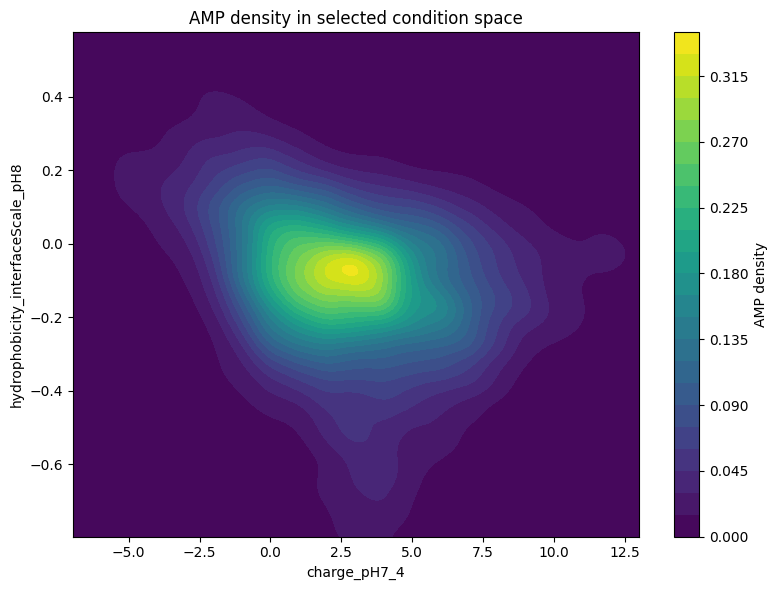

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))

contour = ax.contourf(
    charge_mesh,
    hydro_mesh,
    amp_density,
    levels=30,
)

fig.colorbar(
    contour,
    ax=ax,
    label="AMP density",
)

ax.set_xlabel(charge_col)
ax.set_ylabel(hydro_col)
ax.set_title("AMP density in selected condition space")

fig.tight_layout()
plt.show()

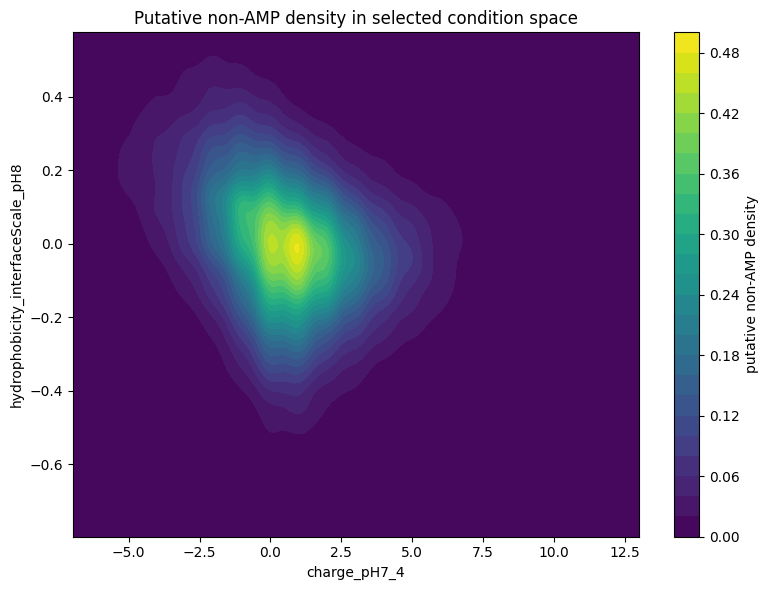

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))

contour = ax.contourf(
    charge_mesh,
    hydro_mesh,
    nonamp_density,
    levels=30,
)

fig.colorbar(
    contour,
    ax=ax,
    label="putative non-AMP density",
)

ax.set_xlabel(charge_col)
ax.set_ylabel(hydro_col)
ax.set_title("Putative non-AMP density in selected condition space")

fig.tight_layout()
plt.show()

In [29]:
amp_density_at_amp = amp_kde(amp_joint)
nonamp_density_at_amp = nonamp_kde(amp_joint)

amp_log_enrichment = (
    np.log(amp_density_at_amp + density_floor)
    - np.log(nonamp_density_at_amp + density_floor)
)

In [30]:
amp_enrichment_summary = pd.Series(
    amp_log_enrichment
).describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
)

amp_enrichment_summary

,0
count,35627.000000
mean,0.857442
std,2.443582
min,-1.872431
5%,-0.976983
25%,-0.520763
50%,0.284604
75%,1.361932
95%,4.095520
max,22.402300


In [31]:
thresholds = [0.0, np.log(2), np.log(3), np.log(5)]

rows = []

for threshold in thresholds:
    rows.append(
        {
            "enrichment_threshold": np.exp(threshold),
            "fraction_of_AMP_above_threshold": (
                amp_log_enrichment > threshold
            ).mean(),
        }
    )

pd.DataFrame(rows)

,enrichment_threshold,fraction_of_AMP_above_threshold
0,1.0,0.566200
1,2.0,0.386364
2,3.0,0.303702
3,5.0,0.215258


In [32]:
target_enrichment = 2.0

target_region = (
    valid_region
    & (enrichment >= target_enrichment)
)

if target_region.any():
    selected_charge = charge_mesh[target_region]
    selected_hydro = hydro_mesh[target_region]

    print(
        "Charge range for E >= 2:",
        selected_charge.min(),
        selected_charge.max(),
    )

    print(
        "Hydrophobicity range for E >= 2:",
        selected_hydro.min(),
        selected_hydro.max(),
    )
else:
    print("No supported grid region with E >= 2.")

Charge range for E >= 2: -6.9639503811761925 12.988206143950396
Hydrophobicity range for E >= 2: -0.7962500000000001 0.5758369230769234


## 14. Robustness of the joint enrichment map

The AMP-enrichment map depends on two analysis choices:

1. KDE bandwidth;
2. the density threshold used to mask poorly supported regions.

To verify that the observed AMP-enriched region is not an artifact of one specific parameterization, we repeat the analysis across several bandwidth multipliers and several support thresholds.

A robust enrichment pattern should persist qualitatively across these settings.

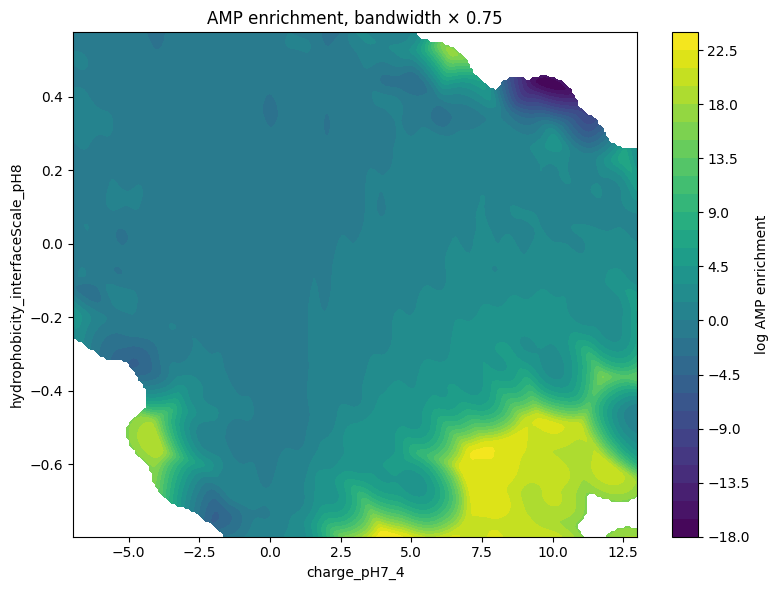

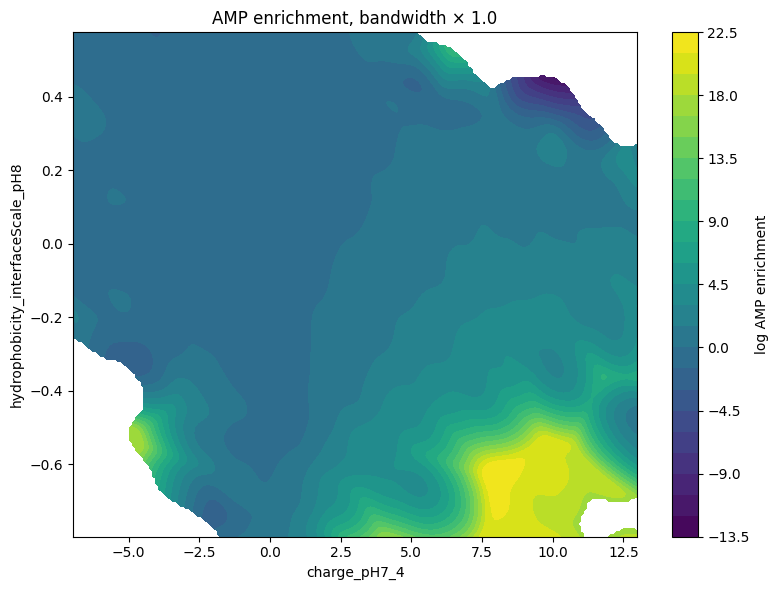

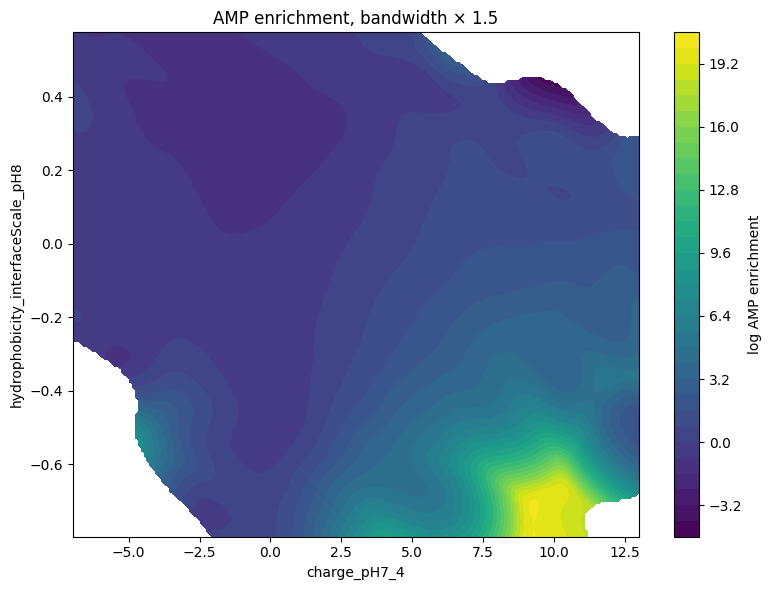

,bandwidth_multiplier,median_log_enrichment,fraction_AMP_E_gt_2
0,0.75,0.261888,0.365397
1,1.00,0.284604,0.386364
2,1.50,0.234382,0.377579


In [34]:
from scipy.stats import gaussian_kde

bandwidth_multipliers = [0.75, 1.0, 1.5]
target_enrichment = 2.0

rows = []

for multiplier in bandwidth_multipliers:
    amp_kde_test = gaussian_kde(amp_joint)
    nonamp_kde_test = gaussian_kde(nonamp_joint)

    amp_kde_test.set_bandwidth(
        bw_method=amp_kde_test.factor * multiplier
    )
    nonamp_kde_test.set_bandwidth(
        bw_method=nonamp_kde_test.factor * multiplier
    )

    amp_density_grid = amp_kde_test(
        grid_points
    ).reshape(charge_mesh.shape)

    nonamp_density_grid = nonamp_kde_test(
        grid_points
    ).reshape(charge_mesh.shape)

    log_enrichment_grid = (
        np.log(amp_density_grid + density_floor)
        - np.log(nonamp_density_grid + density_floor)
    )

    total_density = amp_density_grid + nonamp_density_grid

    support_threshold = np.quantile(
        total_density[total_density > 0],
        0.10,
    )

    valid_region = total_density >= support_threshold

    masked_log_enrichment = np.ma.masked_where(
        ~valid_region,
        log_enrichment_grid,
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    contour = ax.contourf(
        charge_mesh,
        hydro_mesh,
        masked_log_enrichment,
        levels=30,
    )

    fig.colorbar(
        contour,
        ax=ax,
        label="log AMP enrichment",
    )

    ax.set_xlabel(charge_col)
    ax.set_ylabel(hydro_col)
    ax.set_title(
        f"AMP enrichment, bandwidth × {multiplier}"
    )

    fig.tight_layout()
    plt.show()

    amp_density_at_amp = amp_kde_test(amp_joint)
    nonamp_density_at_amp = nonamp_kde_test(amp_joint)

    amp_log_enrichment = (
        np.log(amp_density_at_amp + density_floor)
        - np.log(nonamp_density_at_amp + density_floor)
    )

    rows.append(
        {
            "bandwidth_multiplier": multiplier,
            "median_log_enrichment": np.median(
                amp_log_enrichment
            ),
            "fraction_AMP_E_gt_2": (
                amp_log_enrichment > np.log(target_enrichment)
            ).mean(),
        }
    )

pd.DataFrame(rows)